# Statistical estimation and error bars

📄 Source: https://seaborn.pydata.org/tutorial/error_bars.html

When a plot reduces many points to a summary (mean, median), add **error bars** to show how well that summary represents the data. Seaborn computes both for you; this page is about choosing **what** the error bar shows.

An error bar shows one of two things:
- the **spread** of the underlying data around the estimate, or
- the **uncertainty** of the estimate itself.

They're related (wider spread → more uncertain estimate at the same n), but **uncertainty shrinks as n grows, spread does not**.

Each kind can be built **parametrically** (a formula assuming a distribution shape) or **non-parametrically** (only your data). You choose with the `errorbar` parameter:

| | **Spread** | **Uncertainty** |
| :-- | :-- | :-- |
| **Parametric** | Standard deviation: `errorbar=("sd", scale)` | Standard error: `errorbar=("se", scale)` |
| **Nonparametric** | Percentile interval: `errorbar=("pi", width)` | Confidence interval: `errorbar=("ci", width)` |

The size parameter differs: for parametric bars it's a **multiplier** of the SD/SE; for nonparametric bars it's a **percentile width**.
(`errorbar` arrived in v0.12. Before, the `ci=` parameter did this: `ci=<size>` or `ci="sd"`.)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

sns.set_theme(style="darkgrid")
np.random.seed(sum(map(ord, "errorbars")))
print("seaborn", sns.__version__)

seaborn 0.13.2


Helper from the docs to compare the options. Top: the mean with the chosen error bar (`pointplot`). Bottom: the 100 raw data points (`stripplot`).

In [2]:
def plot_errorbars(arg, **kws):
    np.random.seed(sum(map(ord, "error_bars")))
    x = np.random.normal(0, 1, 100)        # 100 points from a standard normal
    f, axs = plt.subplots(2, figsize=(7, 2), sharex=True, layout="tight")
    sns.pointplot(x=x, errorbar=arg, **kws, capsize=.3, ax=axs[0])   # estimate + error bar
    sns.stripplot(x=x, jitter=.3, ax=axs[1])                        # the raw data

## Measures of data spread

Spread error bars are a compact view of the distribution: 3 numbers instead of a boxplot's 5+.

### Standard deviation error bars

SD ≈ the average distance of points from the mean. `errorbar="sd"` draws **±1 SD**; pass a scale for more. For normal data: ~68% within 1 SD, ~95% within 2, ~99.7% within 3.

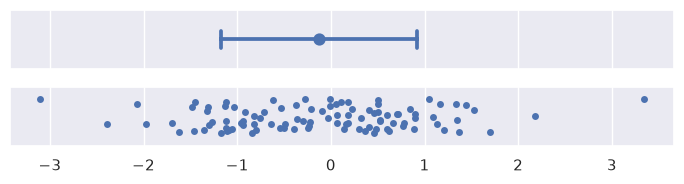

In [3]:
plot_errorbars("sd")

### Percentile interval error bars

Computes percentiles **directly from the sample**. `errorbar="pi"` = 95% interval (2.5th to 97.5th percentile). `("pi", 50)` = the **interquartile range**:

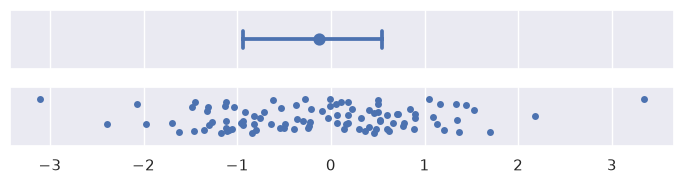

In [4]:
plot_errorbars(("pi", 50))

SD bars are always **symmetric**, which is a problem for **skewed or bounded** data (they can extend to impossible values, e.g. negative prices). Percentile intervals adapt to asymmetry and **never go beyond the data**.

## Measures of estimate uncertainty

If the data are a random sample from a population, the sample mean is an imperfect estimate of the population mean. These bars show the **range of likely values for the true parameter**.

### Standard error bars

SE = SD / √n. `errorbar="se"` draws **±1 SE**:

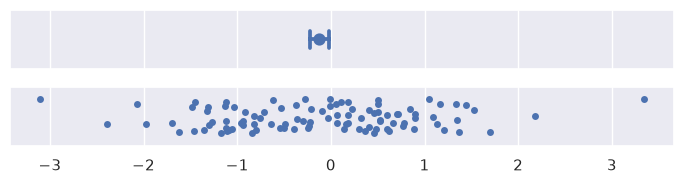

In [5]:
plot_errorbars("se")

### Confidence interval error bars

The nonparametric way uses **bootstrapping**: resample the data **with replacement** many times, recompute the estimate each time, and take a percentile interval of that bootstrap distribution. `errorbar="ci"` = 95% CI:

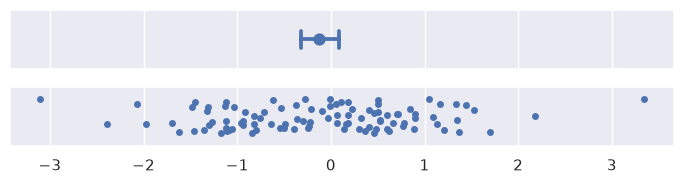

In [6]:
plot_errorbars("ci")

In statistics a CI can be parametric too. A parametric ≈95% CI is **mean ± 2 SE**:

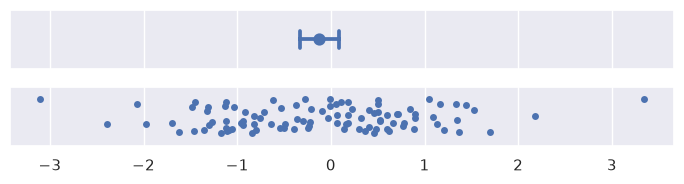

In [7]:
plot_errorbars(("se", 2))

The bootstrap adapts to skewed/bounded data, and it works for **any estimator**, not only the mean (the SE formula is mean-specific):

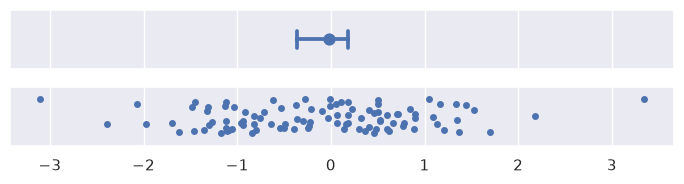

In [8]:
plot_errorbars("ci", estimator="median")

Bootstrapping is random, so bars change slightly on each run. `n_boot` = number of resamples (more = more stable); `seed` = identical results every time:

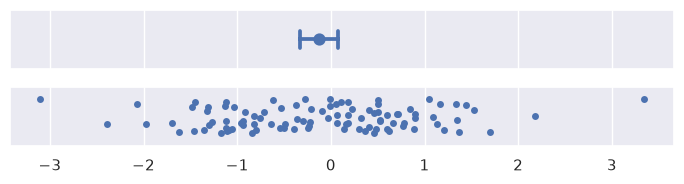

In [9]:
plot_errorbars("ci", n_boot=5000, seed=10)

Bootstrapping is expensive on large data. But with large n the uncertainty is tiny anyway, so a **spread** error bar may be more informative there.

### Custom error bars

Pass a function that takes a vector and returns `(min, max)`:

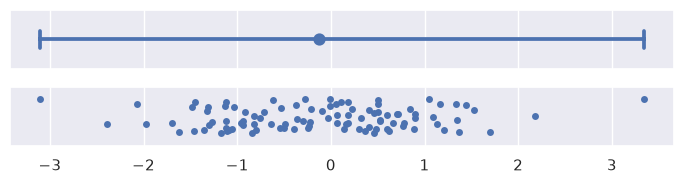

In [10]:
plot_errorbars(lambda x: (x.min(), x.max()))   # the full range of the data

(The full range is simpler as `errorbar=("pi", 100)`.)
Seaborn can't draw error bars from values computed **elsewhere**; use matplotlib (`ax.errorbar`) on top of a seaborn plot for that.

## Error bars on regression fits

For regression models, the error bar is a **band** around the line:

<Axes: >

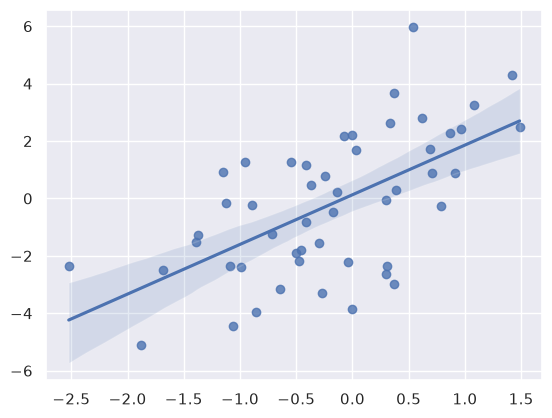

In [11]:
x = np.random.normal(0, 1, 50)
y = x * 2 + np.random.normal(0, 2, size=x.size)   # true slope 2, plus noise
sns.regplot(x=x, y=y)

Regression bands are less flexible: only a confidence interval, sized with `ci=`.

## Are error bars enough?

Always ask whether a summary + error bar is the right plot. Often it **isn't**.
Aggregation makes questions about summaries easier (do group means differ? does it rise over time?) but **hides** the distribution shape and outliers.
**Don't be satisfied with summary statistics: always look at the underlying distributions too.** Combining both in one figure helps (see the categorical notebook).

Text(0.5, 1.0, 'Mean bill per day (95% bootstrap CI) over the raw data')

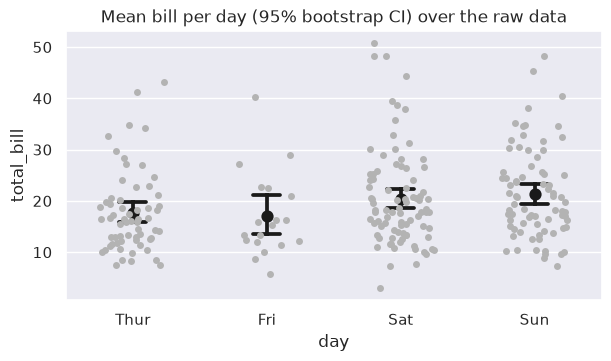

In [12]:
# One way to combine both views (my addition): raw points + mean with a 95% bootstrap CI
tips = sns.load_dataset("tips")
fig, ax = plt.subplots(figsize=(6, 3.5), layout="constrained")
sns.stripplot(data=tips, x="day", y="total_bill", color=".7", jitter=.25, ax=ax)                 # every observation
sns.pointplot(data=tips, x="day", y="total_bill", errorbar=("ci", 95), color="k",
              linestyle="none", capsize=.2, ax=ax)                                                # mean + CI on top
ax.set_title("Mean bill per day (95% bootstrap CI) over the raw data")

## Key takeaways

| Question | `errorbar=` |
| :-- | :-- |
| How spread out are the data? | `"sd"` (symmetric) or `("pi", 50)` / `"pi"` (respects skew and bounds) |
| How precise is my estimate? | `"se"` (±1 SE), `("se", 2)` (≈95% parametric CI), `"ci"` (95% bootstrap CI, any estimator) |
| Reproducible bootstrap | `n_boot=...`, `seed=...` |

- SD/PI don't shrink with more data; SE/CI do.
- Show the raw data alongside the summary whenever you can.